# 2c. Distribution-Specific & Multi-Session Validation

Two validation tests that extend the core parameter recovery (2a):

1. **Hard-A distribution recovery** — does the pipeline work on
   non-uniform stimulus distributions? (The actual experiment uses
   Hard-A/B, not just Uniform.)

2. **GP-linked trajectory recovery** — can SBI recover a *changing*
   parameter across sessions? This is the foundation for 4b's
   parameter dynamics estimation.

**Depends on:** 2a (core recovery validated)

In [1]:
%matplotlib inline
from shared_setup import *
from pathlib import Path

from models.BE_core import BEParams, BEState, BEModel
from models.SC_core import SCParams, SCState, SCModel
from analysis.stimulus_distribution import sample_distribution
from inference.fitting import SBIFitter, train_sbi, SBIResult
from inference.types import ConstantSpec, GPSpec

## 1. Configuration

In [2]:
N_TRIALS = 300
BURN_IN = 1000
N_RECOVERY = 20           # animals per model for recovery test
N_SIMULATIONS = 30_000    # SBI training simulations
N_SESSIONS = 15           # sessions for multi-session test
SEED = 42

## 2. Hard-A Distribution Recovery

Generate synthetic data under Hard-A, train SBI, check recovery.
Compares to Uniform recovery from 2a.

In [3]:
# ── Generate Hard-A synthetic data ──────────────────────────────────────────
rng = np.random.default_rng(SEED)

hard_a_animals = []
for i in range(N_RECOVERY):
    # Sample true parameters
    true_params = {
        'sigma_percep': rng.uniform(0.08, 0.30),
        'A_repulsion': rng.uniform(0.0, 0.3),
        'eta_learning': rng.uniform(0.1, 0.7),
        'eta_relax': rng.uniform(0.05, 0.3),
    }
    
    # Generate Hard-A stimuli
    stim, cat = sample_distribution(N_TRIALS, 'hard_a', rng=rng)
    
    # Simulate
    params = BEParams(**true_params)
    sim_rng = np.random.default_rng(SEED + i + 1000)
    state = BEModel.run_burn_in(params, BEState.initial_uniform(), BURN_IN, SEED + i)
    choices, _, _, _ = BEModel.simulate_session(
        params, state, stim, cat, sim_rng)
    
    hard_a_animals.append({
        'animal_id': f'HARD_A_{i:02d}',
        'true_params': true_params,
        'stimuli': stim,
        'categories': cat,
        'choices': choices,
    })

print(f"Generated {len(hard_a_animals)} Hard-A synthetic animals")

Generated 20 Hard-A synthetic animals


In [4]:
# ── Train SBI on Hard-A stimuli ─────────────────────────────────────────────
# Use the first animal's stimuli as the training distribution
from inference.simulator import create_be_simulator
from inference.priors import create_prior

train_stim = hard_a_animals[0]['stimuli']
train_cat = hard_a_animals[0]['categories']

sim = create_be_simulator(train_stim, train_cat, burn_in=BURN_IN, seed=SEED)
prior = create_prior(model_type='be')

print("Training SNPE on Hard-A distribution...")
try:
    result = train_sbi(
        simulator=sim, prior=prior,
        method='NPE', n_simulations=N_SIMULATIONS,
        seed=SEED, show_progress=True,
    )
    HARD_A_TRAINED = True
    print(f"Training time: {result.training_time:.1f}s")
except Exception as e:
    print(f"SBI training failed: {e}")
    HARD_A_TRAINED = False

Training SNPE on Hard-A distribution...
Round 1/1: Simulating 30000...


/Users/Serkan/Desktop/pro/PhD/main/repos/sound_categorisation/inference/fitting.py:297: UserWarning: Removed 5296 simulations with NaN/inf
  warnings.warn(f"Removed {n_invalid} simulations with NaN/inf")


Round 1/1: Training...
 Neural network successfully converged after 138 epochs.
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 138
        Best validation performance: -4.2908
        -------------------------
        
Training time: 3870.8s


  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

...

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

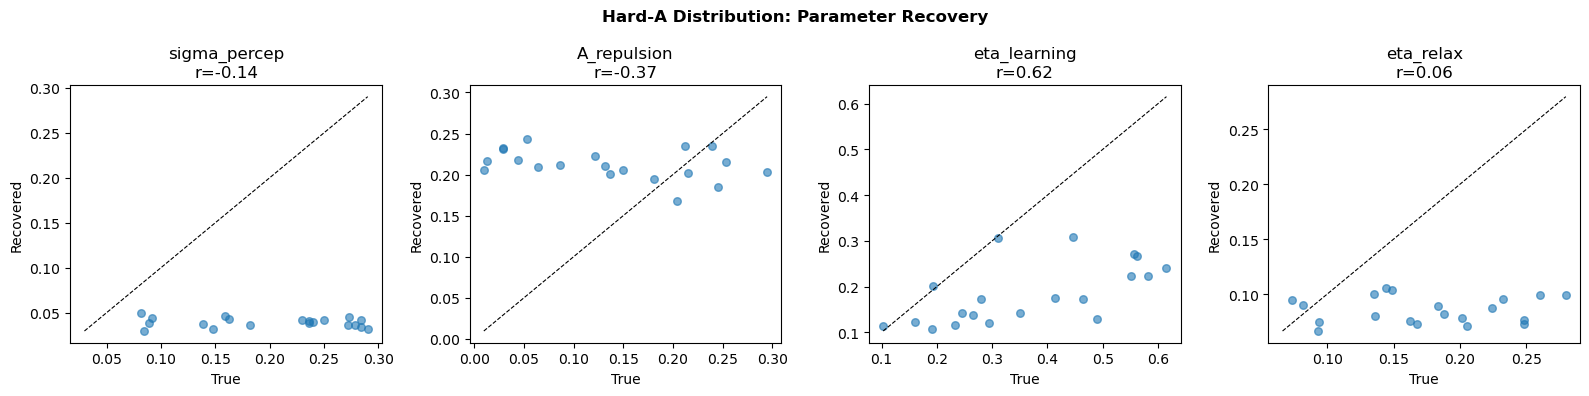

In [5]:
# ── Recovery test ───────────────────────────────────────────────────────────
if HARD_A_TRAINED:
    import torch
    from inference.diagnostics import parameter_recovery, plot_recovery_scatter

    # Compute observed stats for each animal and condition posterior
    recovery_results = []
    for animal in hard_a_animals:
        obs_stats = compute_summary_stats(
            animal['choices'], animal['stimuli'], animal['categories'],
            return_dict=False,
        )
        obs_tensor = torch.tensor(obs_stats, dtype=torch.float32)

        samples = result.sample(5000, x=obs_tensor).numpy()
        median_params = {
            name: float(np.median(samples[:, i]))
            for i, name in enumerate(['sigma_percep', 'A_repulsion',
                                       'eta_learning', 'eta_relax'])
        }
        recovery_results.append({
            'true': animal['true_params'],
            'recovered': median_params,
        })

    # Plot recovery
    param_names = ['sigma_percep', 'A_repulsion', 'eta_learning', 'eta_relax']
    fig, axes = plt.subplots(1, len(param_names), figsize=(4 * len(param_names), 4))
    for ax, pname in zip(axes, param_names):
        true_vals = [r['true'][pname] for r in recovery_results]
        rec_vals = [r['recovered'][pname] for r in recovery_results]
        ax.scatter(true_vals, rec_vals, alpha=0.6, s=30)
        lims = [min(min(true_vals), min(rec_vals)),
                max(max(true_vals), max(rec_vals))]
        ax.plot(lims, lims, 'k--', lw=0.8)
        corr = np.corrcoef(true_vals, rec_vals)[0, 1]
        ax.set_title(f'{pname}\nr={corr:.2f}')
        ax.set_xlabel('True')
        ax.set_ylabel('Recovered')
    fig.suptitle('Hard-A Distribution: Parameter Recovery', fontweight='bold')
    plt.tight_layout()
    plt.show()

## 3. GP-Linked Trajectory Recovery

Can SBI recover a smoothly varying η across sessions?

Protocol:
1. Define a ground-truth η trajectory (high → low, mimicking learning)
2. Simulate multi-session data with that trajectory
3. Fit with GP-linked SBI
4. Compare recovered trajectory to ground truth

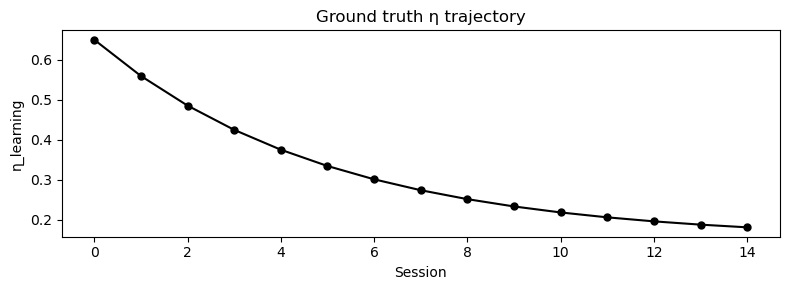

In [6]:
# ── Define ground-truth trajectory ──────────────────────────────────────────
session_indices = np.arange(N_SESSIONS)

# η decays exponentially: high during early learning, low at expert
true_eta_trajectory = 0.15 + 0.50 * np.exp(-0.2 * session_indices)
true_constant_params = {
    'sigma_percep': 0.15,
    'A_repulsion': 0.10,
    'eta_relax': 0.12,
}

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(session_indices, true_eta_trajectory, 'ko-', ms=5)
ax.set_xlabel('Session')
ax.set_ylabel('η_learning')
ax.set_title('Ground truth η trajectory')
plt.tight_layout()
plt.show()

In [7]:
# ── Simulate multi-session data ─────────────────────────────────────────────
rng = np.random.default_rng(SEED)

session_stimuli = []
session_categories = []
session_choices = []

state = BEState.initial_uniform()
for s in range(N_SESSIONS):
    stim = rng.uniform(-1, 1, N_TRIALS)
    cat = (stim > 0).astype(int)
    session_stimuli.append(stim)
    session_categories.append(cat)

    params = BEParams(
        eta_learning=true_eta_trajectory[s],
        **true_constant_params,
    )
    if s == 0:
        state = BEModel.run_burn_in(params, state, BURN_IN, SEED)

    choices, _, state, _ = BEModel.simulate_session(
        params, state, stim, cat, rng)
    session_choices.append(choices)

print(f"Simulated {N_SESSIONS} sessions × {N_TRIALS} trials")

Simulated 15 sessions × 300 trials


In [8]:
# ── Build FittingData for SBIFitter ─────────────────────────────────────────
from behav_utils.data.structures import FittingData

fitting_data = FittingData(
    animal_id='GP_TEST',
    session_ids=[f's{i}' for i in range(N_SESSIONS)],
    session_dates=[None] * N_SESSIONS,
    session_indices=np.arange(N_SESSIONS),
    stimuli=session_stimuli,
    categories=session_categories,
    choices=session_choices,
    no_response=[np.zeros(N_TRIALS, dtype=bool)] * N_SESSIONS,
    not_blockstart=[np.concatenate([[False], np.ones(N_TRIALS - 1, dtype=bool)])] * N_SESSIONS,
    n_sessions=N_SESSIONS,
    trials_per_session=np.full(N_SESSIONS, N_TRIALS),
)

In [9]:
# ── Fit with GP-linked SBI ──────────────────────────────────────────────────
try:
    fitter = SBIFitter(
        fitting_data=fitting_data,
        model_type='be',
        param_links={
            'sigma_percep': ConstantSpec(bounds=(0.05, 0.5)),
            'A_repulsion': ConstantSpec(bounds=(0.0, 0.5)),
            'eta_learning': GPSpec(bounds=(0.05, 0.9), lengthscale=5.0, amplitude=0.15),
            'eta_relax': ConstantSpec(bounds=(0.01, 0.4)),
        },
        burn_in=BURN_IN,
    )
    print(fitter.describe())

    test = fitter.test_simulator()
    print(f"\nSimulator: {test['mean_time_per_sim']:.3f}s/sim")
    print(f"NaN counts: {test['nan_counts']}")

    result = fitter.train(n_simulations=N_SIMULATIONS, seed=SEED)
    trajectories = fitter.extract_trajectories(result)
    GP_FITTED = True
except Exception as e:
    print(f"GP-linked SBI failed: {e}")
    GP_FITTED = False

SBIFitter Configuration
Model: BE
Animal: GP_TEST
Sessions: 15
Theta dim: 18
  Constant: ['sigma_percep', 'A_repulsion', 'eta_relax']
  Varying: ['eta_learning']
Stats: ['accuracy', 'psychometric', 'recency', 'win_stay', 'stimulus_sensitivity'] (120 dims)
Burn-in: 1000

Simulator: 0.216s/sim
NaN counts: [0, 0, 0, 0, 0]
Round 1/1: Simulating 30000...


/Users/Serkan/miniforge3/envs/sound_categorisation/lib/python3.11/site-packages/sbi/utils/user_input_checks_utils.py:88: UserWarning: No prior bounds were passed, consider passing lower_bound and / or upper_bound if your prior has bounded support.
  self.custom_support = build_support(lower_bound, upper_bound)
/Users/Serkan/miniforge3/envs/sound_categorisation/lib/python3.11/site-packages/sbi/utils/user_input_checks_utils.py:90: UserWarning: Prior is lacking mean attribute, estimating prior mean from samples.
  self._set_mean_and_variance()
/Users/Serkan/miniforge3/envs/sound_categorisation/lib/python3.11/site-packages/sbi/utils/user_input_checks_utils.py:90: UserWarning: Prior is lacking variance attribute, estimating prior variance from samples.
  self._set_mean_and_variance()
/Users/Serkan/miniforge3/envs/sound_categorisation/lib/python3.11/site-packages/sbi/inference/trainers/npe/npe_base.py:196: UserWarning: Data has extreme outliers in dimension(s) [42, 50, 82, 114] (beyond 10.0x

Round 1/1: Training...
 Neural network successfully converged after 215 epochs.
        -------------------------
        ||||| ROUND 1 STATS |||||:
        -------------------------
        Epochs trained: 215
        Best validation performance: -57.5965
        -------------------------
        


  0%|          | 0/5000 [00:00<?, ?it/s]

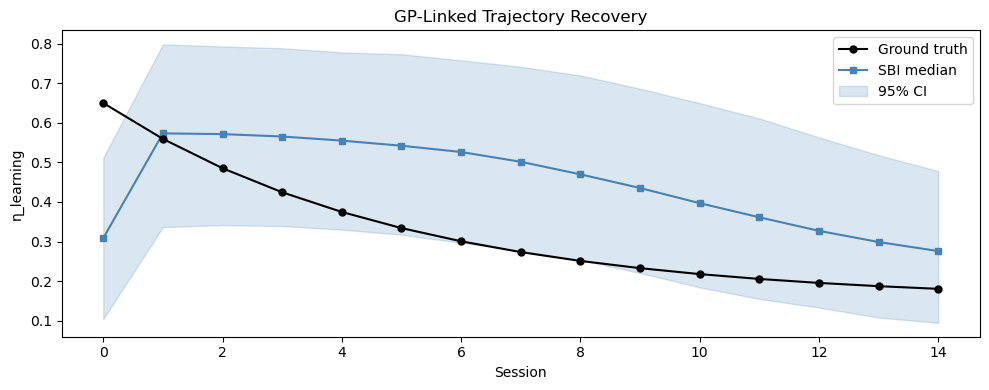

Trajectory recovery: r=0.415, RMSE=0.1839, 95% CI coverage=80.0%
  sigma_percep: true=0.150, recovered=0.105 [0.018, 0.190]
  A_repulsion: true=0.100, recovered=0.269 [0.110, 0.401]
  eta_relax: true=0.120, recovered=0.260 [0.083, 0.451]


In [10]:
# ── Compare recovered vs true trajectory ────────────────────────────────────
if GP_FITTED:
    eta_traj = trajectories['eta_learning']

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(session_indices, true_eta_trajectory, 'ko-', ms=5,
            label='Ground truth', zorder=5)
    ax.plot(session_indices, eta_traj['median'], 's-', color='steelblue',
            ms=5, label='SBI median')
    ax.fill_between(session_indices, eta_traj['ci_low'], eta_traj['ci_high'],
                     color='steelblue', alpha=0.2, label='95% CI')
    ax.set_xlabel('Session')
    ax.set_ylabel('η_learning')
    ax.set_title('GP-Linked Trajectory Recovery')
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Recovery quality
    corr = np.corrcoef(true_eta_trajectory, eta_traj['median'])[0, 1]
    rmse = np.sqrt(np.mean((true_eta_trajectory - eta_traj['median'])**2))
    coverage = np.mean(
        (true_eta_trajectory >= eta_traj['ci_low']) &
        (true_eta_trajectory <= eta_traj['ci_high'])
    )
    print(f"Trajectory recovery: r={corr:.3f}, RMSE={rmse:.4f}, "
          f"95% CI coverage={coverage:.1%}")

    # Constant parameter recovery
    for name in ['sigma_percep', 'A_repulsion', 'eta_relax']:
        traj = trajectories[name]
        true_val = true_constant_params[name]
        print(f"  {name}: true={true_val:.3f}, "
              f"recovered={traj['median']:.3f} "
              f"[{traj['ci_low']:.3f}, {traj['ci_high']:.3f}]")